In [14]:
import mlflow
import pandas as pd
import os
from workspace.sources.experiments.metrics import Precision, standard_evaluation_metrics, standard_metrics, Loss
from workspace.sources.experiments.visualizations.plots import plot_confusion_matrix, plot_roc_curve
from workspace.sources.experiments.utils import get_best_models_by_metrics
from workspace.sources.experiments.visualizations.tables import METRICS_PLOT_NAMES_MAPPING
import ast

mlflow.set_tracking_uri('../../mlruns')

In [4]:
experiment_name = 'prefinal-bert-v2'

In [5]:
def flatten_dict(d: dict, flatten_key: str) -> dict:
    return {
        outer_k: (inner[flatten_key] if isinstance(inner, dict) and flatten_key in inner else inner)
        for outer_k, inner in d.items()
    }


def get_run_artifacts_path(run_id):
    client = mlflow.tracking.MlflowClient()
    run_artifacts_path = client.download_artifacts(run_id=run_id, path='')
    return run_artifacts_path

### ReCOVery Dataset

In [6]:
dataset_name = 'recovery'

best_models_by_metrics_flattened = flatten_dict(get_best_models_by_metrics(dataset_name, [experiment_name]),
                                                flatten_key=experiment_name)

#### Confusion Matrix


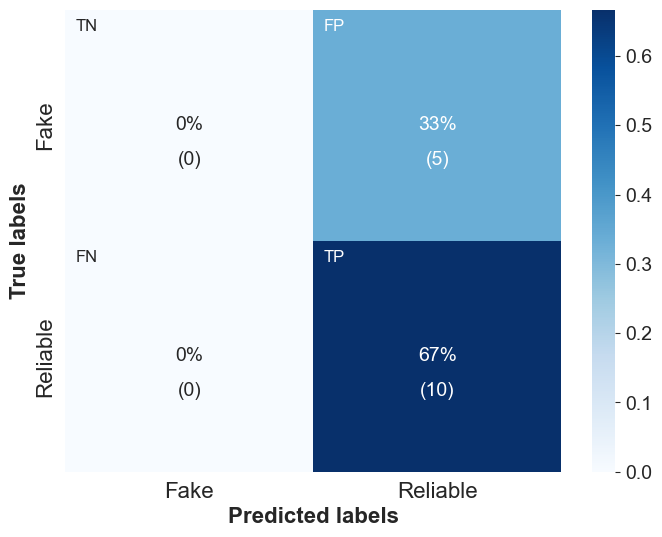

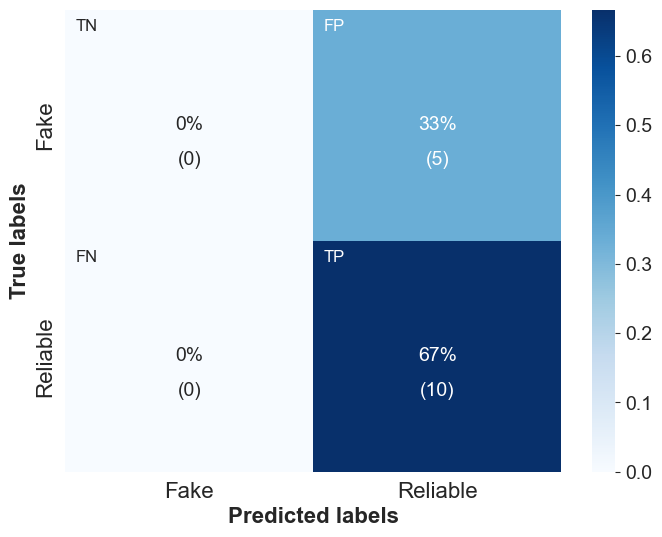

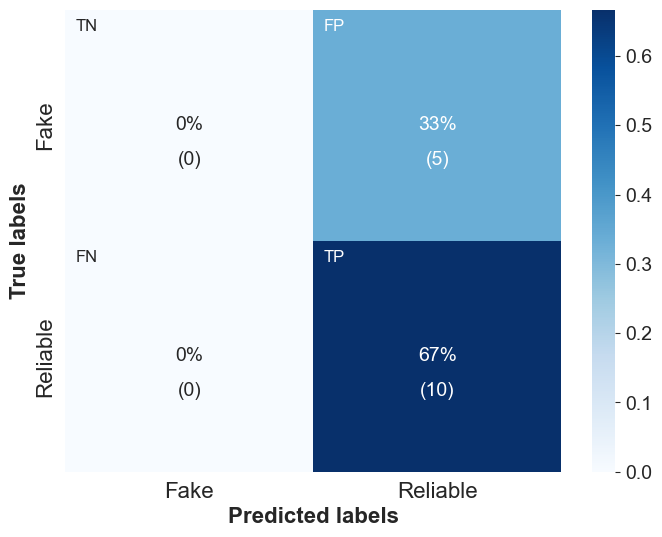

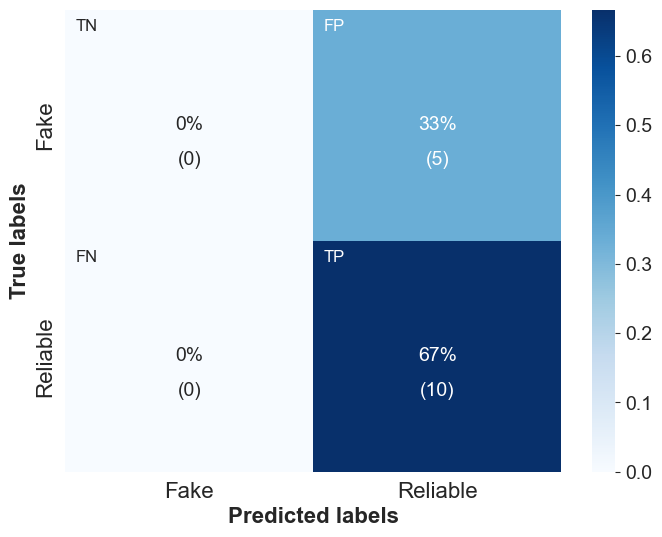

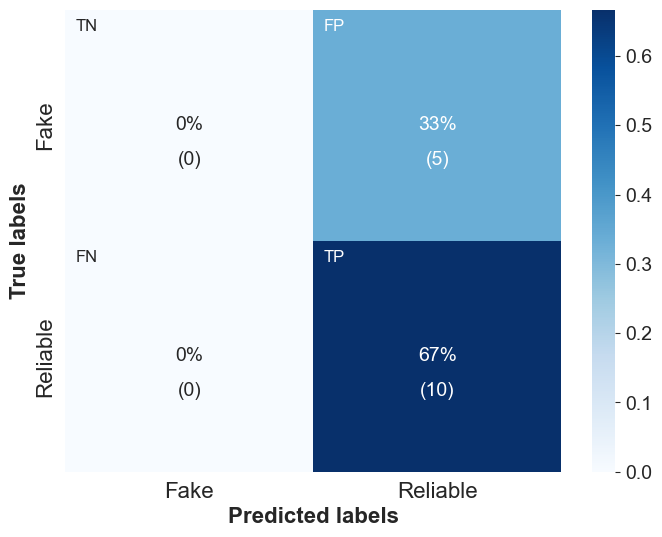

In [7]:
for metric in standard_evaluation_metrics:
    if metric.name == 'accuracy':
        continue
    best_run = best_models_by_metrics_flattened[metric.name]
    best_model_run_id = best_run.info.run_id
    run_artifacts_path = get_run_artifacts_path(best_model_run_id)
    plot_confusion_matrix(run_artifacts_path,
                          metric,
                          dataset_name=dataset_name)

#### ROC Curve

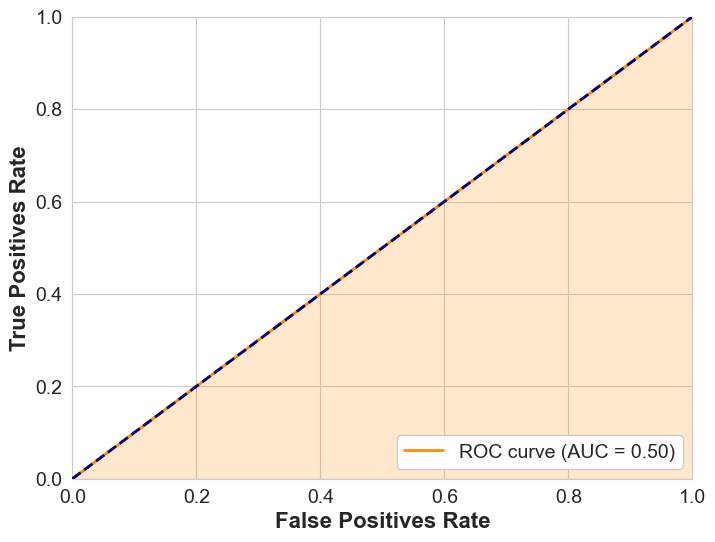

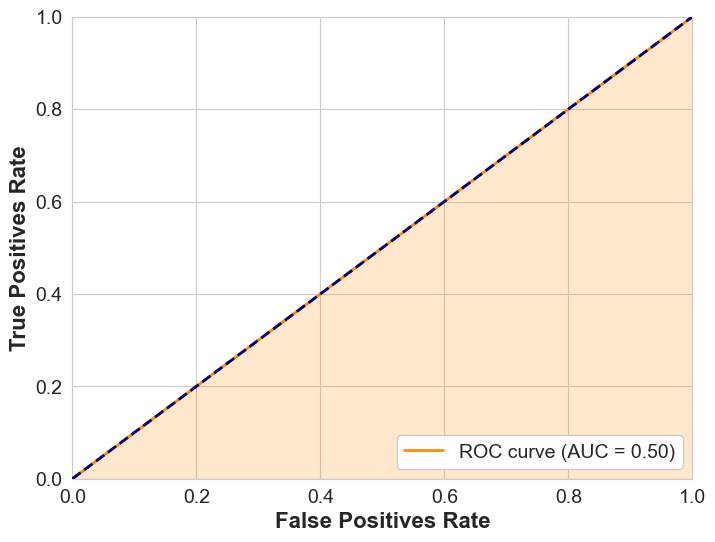

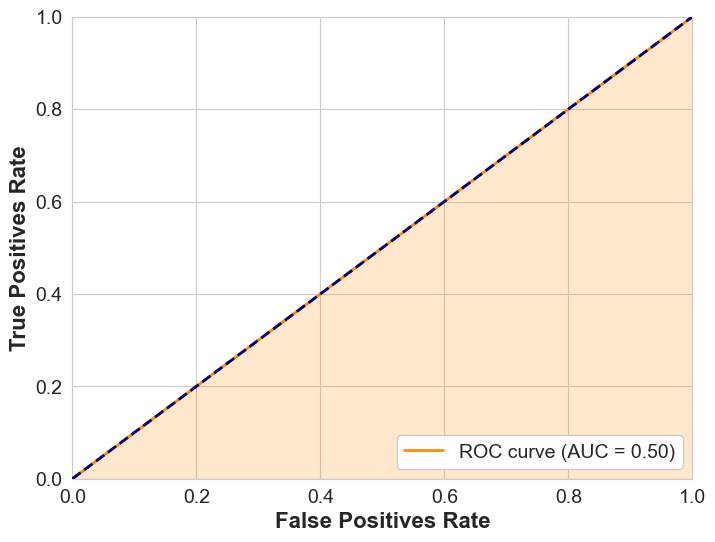

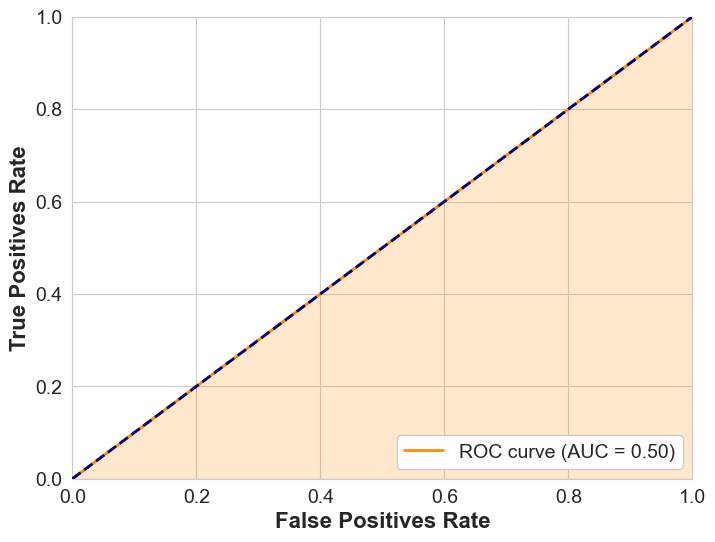

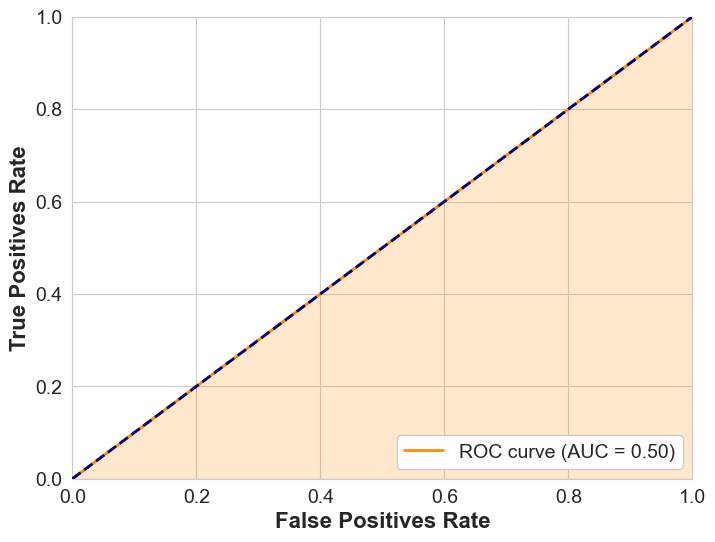

In [9]:
for metric in standard_evaluation_metrics:
    if metric.name == 'accuracy':
        continue
    best_run = best_models_by_metrics_flattened[metric.name]
    best_model_run_id = best_run.info.run_id
    run_artifacts_path = get_run_artifacts_path(best_model_run_id)
    plot_roc_curve(run_artifacts_path,
                   metric,
                   dataset_name=dataset_name)

#### Hyperparameters Tables

##### Model Hyperparameters

In [22]:
hyperparameters_by_metric = dict()
for metric in standard_evaluation_metrics:
    if metric.name == 'accuracy':
        continue
    model_hparams_dict_str = best_models_by_metrics_flattened[metric.name].data.params['model_input_hyperparameters']
    model_hparams_dict = ast.literal_eval(model_hparams_dict_str)

    hyperparameters_by_metric[metric] = model_hparams_dict

for metric, model_hparams in hyperparameters_by_metric.items():
    df = pd.DataFrame(list(model_hparams.items()), columns=['Hyperparameter', 'Value'])
    output_dir = f'assets/{dataset_name}/model_hyperparameters/'
    os.makedirs(output_dir, exist_ok=True)
    output_path = os.path.join(output_dir, f'model_hyperparameters_table_by_{metric.name}.tex')
    float_format_fn = lambda x: f'{x:.3f}' if isinstance(x, (float, int)) else str(x).replace('_', '\\_')
    latex_table = df.to_latex(index=False,
                              escape=True,
                              float_format=float_format_fn,
                              column_format='|c||c|')
    # Add horizontal lines between each row
    latex_table = latex_table.replace('\\\\', '\\\\ \\midrule')
    with open(output_path, 'w') as f:
        f.write(latex_table)


##### Preprocessing Pipeline

In [43]:
best_models_by_metrics_flattened['precision'].data.params['model_input_hyperparameters']

"{'epochs': 10, 'batch_size': 16, 'eval_batch_size': 16, 'learning_rate': 5e-05, 'lr_scheduler': 'linear', 'weight_decay': 0.001, 'optimizer': 'adamw_torch', 'early_stopping_patience': 3, 'early_stopping_threshold': 0.01}"